In [1]:
from torch_geometric.nn import Node2Vec
import os.path as osp
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch_geometric.datasets import Planetoid
from torch.utils.tensorboard import SummaryWriter

# from tqdm.notebook import tqdm

In [2]:
dataset = "Cora"
path = osp.join("../data/raw/", "Cora-node2vec", dataset)
dataset = Planetoid(path, dataset)
data = dataset[0]

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Node2Vec(
    data.edge_index,
    embedding_dim=128,
    walk_length=20,  # lenght of rw
    context_size=10,
    walks_per_node=20,
    num_negative_samples=1,
    p=200,
    q=1,  # bias parameters
    sparse=True,
).to(device)

In [4]:
loader = model.loader(batch_size=128, shuffle=True, num_workers=4)

for idx, (pos_rw, neg_rw) in enumerate(loader):
    print(idx, pos_rw.shape, neg_rw.shape)

0 torch.Size([28160, 10]) torch.Size([28160, 10])
1 torch.Size([28160, 10]) torch.Size([28160, 10])
2 torch.Size([28160, 10]) torch.Size([28160, 10])
3 torch.Size([28160, 10]) torch.Size([28160, 10])
4 torch.Size([28160, 10]) torch.Size([28160, 10])
5 torch.Size([28160, 10]) torch.Size([28160, 10])
6 torch.Size([28160, 10]) torch.Size([28160, 10])
7 torch.Size([28160, 10]) torch.Size([28160, 10])
8 torch.Size([28160, 10]) torch.Size([28160, 10])
9 torch.Size([28160, 10]) torch.Size([28160, 10])
10 torch.Size([28160, 10]) torch.Size([28160, 10])
11 torch.Size([28160, 10]) torch.Size([28160, 10])
12 torch.Size([28160, 10]) torch.Size([28160, 10])
13 torch.Size([28160, 10]) torch.Size([28160, 10])
14 torch.Size([28160, 10]) torch.Size([28160, 10])
15 torch.Size([28160, 10]) torch.Size([28160, 10])
16 torch.Size([28160, 10]) torch.Size([28160, 10])
17 torch.Size([28160, 10]) torch.Size([28160, 10])
18 torch.Size([28160, 10]) torch.Size([28160, 10])
19 torch.Size([28160, 10]) torch.Size([28

In [5]:
import networkx as nx

edge_tuples = [tuple(x) for x in data.edge_index.numpy().transpose()]
G = nx.from_edgelist(edge_tuples)
pos = nx.spring_layout(G, center=[0.5, 0.5])
nx.set_node_attributes(G, pos, "pos")

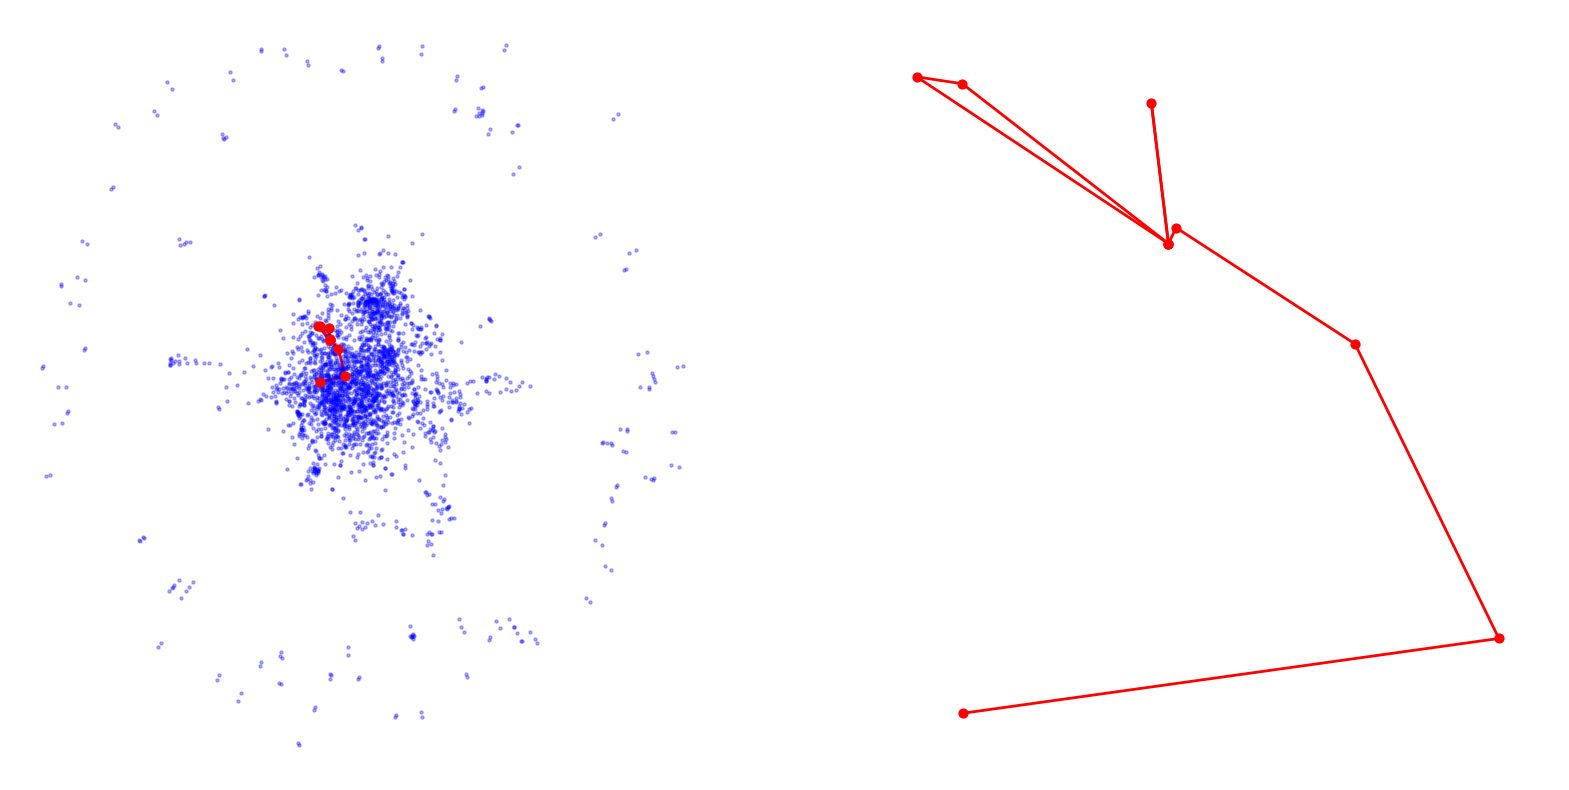

In [6]:
nodelist = next(enumerate(loader))[1][0][0].tolist()
walk = nx.path_graph(len(nodelist))
nx.set_node_attributes(
    walk, {idx: pos[node_id] for idx, node_id in enumerate(nodelist)}, "pos"
)

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(1, 2, 1)
nx.draw_networkx_nodes(
    G,
    ax=ax,
    pos=nx.get_node_attributes(G, "pos"),
    node_size=5,
    alpha=0.3,
    node_color="b",
)
nx.draw(
    walk,
    node_size=40,
    node_color="r",
    ax=ax,
    pos=nx.get_node_attributes(walk, "pos"),
    width=2,
    edge_color="r",
)
ax = fig.add_subplot(1, 2, 2)
nx.draw(
    walk,
    node_size=40,
    node_color="r",
    ax=ax,
    pos=nx.get_node_attributes(walk, "pos"),
    width=2,
    edge_color="r",
)

---
## Traning

In [7]:
model = Node2Vec(
    data.edge_index,
    embedding_dim=128,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1,
    q=1,
    sparse=True,
).to(device)

loader = model.loader(batch_size=128, shuffle=True, num_workers=4)
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01)


def train():
    model.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer.zero_grad()
        loss = model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def test():
    model.eval()
    z = model()
    acc = model.test(
        z[data.train_mask],
        data.y[data.train_mask],
        z[data.test_mask],
        data.y[data.test_mask],
        max_iter=150,
    )
    return acc

In [8]:
import socket
from datetime import datetime

SYSTEM_ID = socket.gethostname()
DATETIME_ID = datetime.now().strftime("%b%d_%H-%M-%S")
writer = SummaryWriter(log_dir=f"../runs/{DATETIME_ID}_{SYSTEM_ID}/")

for epoch in range(1, 51):
    loss = train()
    acc = test()
    writer.add_scalar("training_loss", loss, epoch)
    writer.add_scalar("test_accuracy", acc, epoch)

    writer.add_embedding(
        mat=model(torch.arange(data.num_nodes, device=device)),
        metadata=list(data.y.cpu().numpy()),
        global_step=epoch,
        tag="node_embeddings",
    )
    print(f"Epoch: {epoch:02d}, Loss: {loss:.4f}, Acc: {acc:.4f}")

writer.close()

Epoch: 01, Loss: 8.1038, Acc: 0.1430
Epoch: 02, Loss: 6.0544, Acc: 0.1710
Epoch: 03, Loss: 4.9520, Acc: 0.1960
Epoch: 04, Loss: 4.1329, Acc: 0.2330
Epoch: 05, Loss: 3.4821, Acc: 0.2650
Epoch: 06, Loss: 2.9629, Acc: 0.3140
Epoch: 07, Loss: 2.5459, Acc: 0.3480
Epoch: 08, Loss: 2.2177, Acc: 0.3700
Epoch: 09, Loss: 1.9583, Acc: 0.3960
Epoch: 10, Loss: 1.7455, Acc: 0.4150
Epoch: 11, Loss: 1.5736, Acc: 0.4460
Epoch: 12, Loss: 1.4315, Acc: 0.4710
Epoch: 13, Loss: 1.3219, Acc: 0.4940
Epoch: 14, Loss: 1.2329, Acc: 0.5170
Epoch: 15, Loss: 1.1608, Acc: 0.5430
Epoch: 16, Loss: 1.1066, Acc: 0.5620
Epoch: 17, Loss: 1.0584, Acc: 0.5750
Epoch: 18, Loss: 1.0244, Acc: 0.5880
Epoch: 19, Loss: 0.9946, Acc: 0.6030
Epoch: 20, Loss: 0.9717, Acc: 0.6170
Epoch: 21, Loss: 0.9527, Acc: 0.6160
Epoch: 22, Loss: 0.9373, Acc: 0.6240
Epoch: 23, Loss: 0.9236, Acc: 0.6350
Epoch: 24, Loss: 0.9118, Acc: 0.6420
Epoch: 25, Loss: 0.9017, Acc: 0.6490
Epoch: 26, Loss: 0.8949, Acc: 0.6580
Epoch: 27, Loss: 0.8866, Acc: 0.6610
E

In [ ]:
z = model(torch.arange(data.num_nodes, device=device))
z.shape

In [ ]:
training_embeddings = model()

In [ ]:
torch.arange(data.num_nodes, device=device)

In [ ]:
model(torch.tensor(5).to(device))

In [12]:
z = model(torch.arange(data.num_nodes, device=device))

In [10]:
y = data.y.cpu().numpy()
y

array([3, 4, 4, ..., 3, 3, 3])

In [16]:
z.shape

torch.Size([2708, 128])

In [15]:
z[1].shape

torch.Size([128])

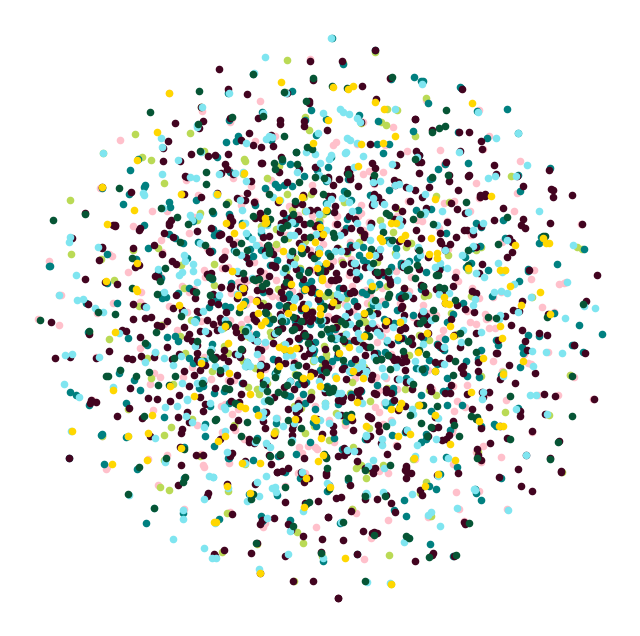

In [8]:
@torch.no_grad()
def plot_points(colors):
    model.eval()
    z = model(torch.arange(data.num_nodes, device=device))
    z = TSNE(n_components=2).fit_transform(z.cpu().numpy())
    y = data.y.cpu().numpy()

    plt.figure(figsize=(8, 8))
    for i in range(dataset.num_classes):
        plt.scatter(z[y == i, 0], z[y == i, 1], s=20, color=colors[i])
    plt.axis("off")
    plt.show()


colors = ["#ffc0cb", "#bada55", "#008080", "#420420", "#7fe5f0", "#065535", "#ffd700"]
plot_points(colors)